In [9]:
from preprocessing import FPDataLoader
from model import BasicCNN
import matplotlib.pyplot as plt
import numpy as np

IDs Shape: (3500,)
Images Shape: (3500, 224, 224, 3)
Labels Shape: (3500,)
Tabular Shape: (3500, 3)


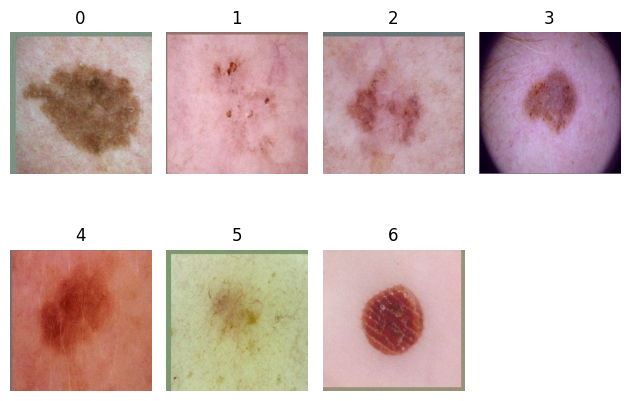

In [2]:
loader = FPDataLoader()
train_ids, train_images, train_labels, train_tabular, metadata = loader.get_cancer_data()
loader.show_sample_imgs(train_images=train_images, train_labels=train_labels)


unique elements:  [0 1 2 3 4 5 6]
counts:  [ 384  205  120  388 2314   38   51]
(3500, 3)


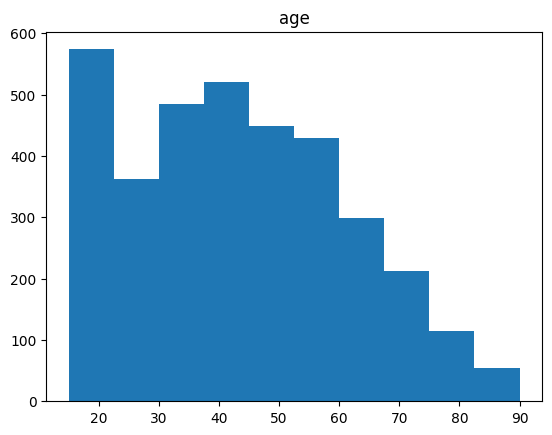

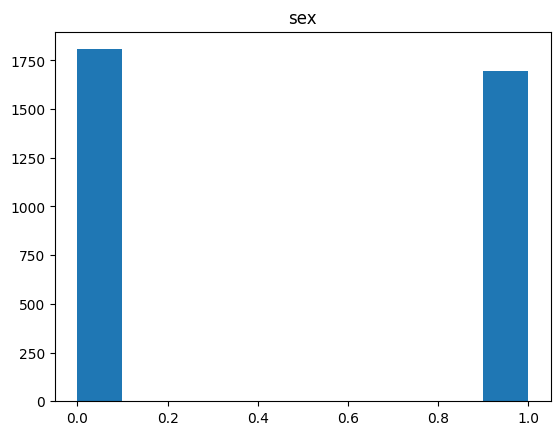

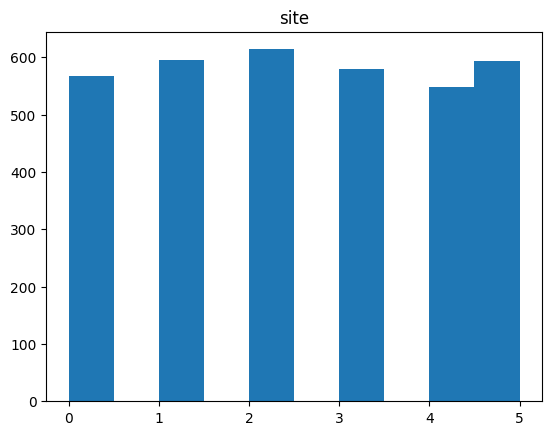

In [17]:
num_unique, counts = np.unique(train_labels, return_counts=True)
print("unique elements: ", num_unique)
print("counts: ", counts)

print(train_tabular.shape)
labels = ["age", "sex", "site"]
i = 0

for col in train_tabular.T:
    plt.figure()
    plt.title(labels[i])
    plt.hist(col)
    i+=1

In [3]:
def train_one_epoch(model, X_train, y_train, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X, y in zip(X_train, y_train):
        X, y = X.to(DEVICE), y.to(DEVICE).squeeze().long()
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

In [5]:
def evaluate(model, X_test, y_test, criterion):
    model.eval()    #this ensures that the dropout layers are not running during evaluation
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for X, y in zip(X_test, y_test):
            X, y = X.to(DEVICE), y.to(DEVICE).squeeze().long()
            out = model(X)
            total_loss += criterion(out, y).item() * X.size(0)
            correct    += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

In [6]:
def run_experiment(model, num_epochs):

    criterion = nn.CrossEntropyLoss() #this loss converts the real values into probabilites in it first
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = {"train_loss": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        tr_loss          = train_one_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc  = evaluate(model, test_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | train loss {tr_loss:.4f} | "
                  f"test loss {te_loss:.4f} | test acc {te_acc:.3f}")
    return history

In [ ]:
def plot_results(model, num_epochs):
    epochs  = range(1, num_epochs + 1)

    colors = ["#e74c3c", "#2ecc71"]

    # Loss curves
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    ax.plot(epochs, model_results["train_loss"], label="Train Loss", color=colors[0], linestyle="--", alpha=0.5)
    ax.plot(epochs, hist_base_results["test_loss"],  label="Test Loss", color=colors[1], linestyle="-")
    ax.set_title("Loss (— test,  -- train)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.show()

In [ ]:
EPOCHS=40
num_classes=2

model_base = BasicCNN(num_classes)
hist_base = run_experiment(model_base, EPOCHS)

NameError: name 'BasicCNN' is not defined